# 🔧 UHI Sumbar — FIX v2

## Root cause masalah saat ini:

| # | Masalah | Penjelasan |
|---|---------|------------|
| 1 | **File TIF ada di folder salah** | GEE **tidak support subfolder** (`folder='UHI_Sumbar/raw_tif'`). Slash `/` diabaikan, file tersimpan di folder bernama `UHI_Sumbar raw_tif` (dengan spasi) atau di root Drive |
| 2 | **File duplikat `(1).tif`** | Export dari session lama dan baru conflict → Google Drive auto-rename jadi `Padang_2015 (1).tif` |
| 3 | **`tif_index` kosong** | Scanner hanya cek `UHI_Sumbar/raw_tif/` padahal file ada di tempat lain |

## Strategi fix:
- **Cell 0**: Setup
- **Cell SCAN**: Temukan SEMUA file TIF di seluruh Drive → bangun index lokasi
- **Cell CLEAN**: Hapus duplikat `(1).tif`
- **Cell MOVE**: Pindahkan semua TIF ke folder yang benar dan konsisten
- **Cell EXPORT**: Export ulang hanya tahun yang benar-benar missing
- **Cell PREPROCESS**: Preprocessing dengan path yang sudah benar
- **Cell ML**: K-Means + RF + XGBoost
- **Cell SAVE**: Simpan semua output

---
## 🔌 CELL 0 — Setup

In [2]:
!pip install earthengine-api geemap geopandas rasterstats xgboost -q

import ee, os, json, shutil, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from rasterstats import zonal_stats
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

ee.Authenticate()
PROJECT_ID = 'gearthengine-498601'
ee.Initialize(project=PROJECT_ID)

# ── Path yang BENAR: folder flat tanpa subfolder ──
DRIVE_ROOT   = Path('/content/drive/MyDrive')
BASE_DIR     = DRIVE_ROOT / 'UHI_Sumbar'
# Folder TIF yang benar: FLAT, tanpa slash
TIF_DIR_CORRECT = BASE_DIR / 'raw_tif'
TIF_DIR_CORRECT.mkdir(parents=True, exist_ok=True)

for sub in ['admin','processed','models','exports']:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)

KOTA_LIST = ['Bukittinggi','Padang','Padang_Panjang',
             'Pariaman','Payakumbuh','Sawahlunto','Solok']
YEARS     = list(range(2015, 2026))

print('✅ Setup selesai!')
print(f'📂 BASE_DIR    : {BASE_DIR}')
print(f'📂 TIF_DIR     : {TIF_DIR_CORRECT}')
print(f'🏙️  KOTA_LIST  : {KOTA_LIST}')

Mounted at /content/drive
✅ Setup selesai!
📂 BASE_DIR    : /content/drive/MyDrive/UHI_Sumbar
📂 TIF_DIR     : /content/drive/MyDrive/UHI_Sumbar/raw_tif
🏙️  KOTA_LIST  : ['Bukittinggi', 'Padang', 'Padang_Panjang', 'Pariaman', 'Payakumbuh', 'Sawahlunto', 'Solok']


---
## 🔍 CELL SCAN — Temukan SEMUA file TIF di seluruh Drive

In [3]:
print('🔍 Mencari semua file .tif di Google Drive...\n')
print('(proses ini mungkin 1-2 menit jika Drive penuh)\n')

# Scan beberapa lokasi kemungkinan folder GEE export
SEARCH_PATHS = [
    DRIVE_ROOT / 'UHI_Sumbar' / 'raw_tif',
    DRIVE_ROOT / 'UHI_Sumbar raw_tif',        # GEE flatten slash → spasi
    DRIVE_ROOT / 'UHI_Sumbar',
    DRIVE_ROOT,                                 # root Drive
]

all_tif_found = []  # list of Path

for search_path in SEARCH_PATHS:
    if search_path.exists():
        found = list(search_path.glob('*.tif'))  # hanya 1 level
        if found:
            print(f'✅ Ditemukan {len(found)} file di: {search_path}')
            for f in sorted(found)[:5]:
                print(f'   {f.name}')
            if len(found) > 5:
                print(f'   ... dan {len(found)-5} lainnya')
            all_tif_found.extend(found)
        else:
            print(f'📂 Folder ada tapi kosong: {search_path}')
    else:
        print(f'❌ Folder tidak ada: {search_path}')

print(f'\n📊 Total file TIF ditemukan: {len(all_tif_found)}')

# Identifikasi duplikat (nama dengan " (1)" atau " (2)")
duplicates = [f for f in all_tif_found if ' (' in f.name]
originals  = [f for f in all_tif_found if ' (' not in f.name]
print(f'   File original (bersih)  : {len(originals)}')
print(f'   File duplikat "(1)" dst : {len(duplicates)}')
if duplicates:
    print('   Contoh duplikat:')
    for d in duplicates[:5]:
        print(f'     {d}')

🔍 Mencari semua file .tif di Google Drive...

(proses ini mungkin 1-2 menit jika Drive penuh)

📂 Folder ada tapi kosong: /content/drive/MyDrive/UHI_Sumbar/raw_tif
✅ Ditemukan 98 file di: /content/drive/MyDrive/UHI_Sumbar raw_tif
   Bukittinggi_2015.tif
   Bukittinggi_2017.tif
   Bukittinggi_2018.tif
   Bukittinggi_2019.tif
   Bukittinggi_2021.tif
   ... dan 93 lainnya
📂 Folder ada tapi kosong: /content/drive/MyDrive/UHI_Sumbar
📂 Folder ada tapi kosong: /content/drive/MyDrive

📊 Total file TIF ditemukan: 98
   File original (bersih)  : 65
   File duplikat "(1)" dst : 33
   Contoh duplikat:
     /content/drive/MyDrive/UHI_Sumbar raw_tif/Solok_2017 (1).tif
     /content/drive/MyDrive/UHI_Sumbar raw_tif/Solok_2016 (1).tif
     /content/drive/MyDrive/UHI_Sumbar raw_tif/Solok_2015 (1).tif
     /content/drive/MyDrive/UHI_Sumbar raw_tif/Solok_2018 (1).tif
     /content/drive/MyDrive/UHI_Sumbar raw_tif/Solok_2021 (1).tif


---
## 🧹 CELL CLEAN & MOVE — Bersihkan duplikat + pindahkan semua TIF ke folder yang benar

In [4]:
# ── Step 1: Hapus file duplikat " (1).tif" ──
print('🗑️  Menghapus file duplikat...')
deleted = 0
for dup in duplicates:
    try:
        dup.unlink()
        print(f'   Deleted: {dup.name}')
        deleted += 1
    except Exception as e:
        print(f'   ⚠️  Gagal hapus {dup.name}: {e}')
print(f'✅ {deleted} file duplikat dihapus\n')

# ── Step 2: Pindahkan semua TIF ke TIF_DIR_CORRECT ──
print(f'📦 Memindahkan semua TIF ke: {TIF_DIR_CORRECT}')
moved = 0
for src_file in originals:
    dest = TIF_DIR_CORRECT / src_file.name
    if src_file.resolve() == dest.resolve():
        continue  # sudah di tempat yang benar
    try:
        shutil.move(str(src_file), str(dest))
        print(f'   Moved: {src_file.name}')
        moved += 1
    except Exception as e:
        print(f'   ⚠️  {src_file.name}: {e}')
print(f'✅ {moved} file dipindahkan\n')

# ── Step 3: Verifikasi final ──
final_tifs = sorted(TIF_DIR_CORRECT.glob('*.tif'))
print(f'📁 File TIF di folder yang benar: {len(final_tifs)}')

# Rangkum coverage per kota
coverage = {}
for f in final_tifs:
    stem = f.stem  # e.g. 'Bukittinggi_2015'
    parts = stem.rsplit('_', 1)
    if len(parts) == 2 and parts[1].isdigit():
        k, y = parts[0], int(parts[1])
        coverage.setdefault(k, []).append(y)

print('\nCoverage per kota:')
for kota in KOTA_LIST:
    years_have = sorted(coverage.get(kota, []))
    years_miss = [y for y in YEARS if y not in years_have]
    status = '✅' if len(years_have) >= 8 else '⚠️ '
    print(f'  {status} {kota}: {len(years_have)} tahun ada | missing: {years_miss}')

🗑️  Menghapus file duplikat...
   Deleted: Solok_2017 (1).tif
   Deleted: Solok_2016 (1).tif
   Deleted: Solok_2015 (1).tif
   Deleted: Solok_2018 (1).tif
   Deleted: Solok_2021 (1).tif
   Deleted: Solok_2019 (1).tif
   Deleted: Solok_2022 (1).tif
   Deleted: Solok_2023 (1).tif
   Deleted: Solok_2024 (1).tif
   Deleted: Padang_2015 (1).tif
   Deleted: Solok_2025 (1).tif
   Deleted: Solok_2020 (1).tif
   Deleted: Padang_2016 (1).tif
   Deleted: Padang_2018 (1).tif
   Deleted: Padang_2017 (1).tif
   Deleted: Padang_2020 (1).tif
   Deleted: Padang_2022 (1).tif
   Deleted: Padang_2021 (1).tif
   Deleted: Padang_2023 (1).tif
   Deleted: Padang_2024 (1).tif
   Deleted: Padang_2025 (1).tif
   Deleted: Pariaman_2015 (1).tif
   Deleted: Padang_2019 (1).tif
   Deleted: Pariaman_2017 (1).tif
   Deleted: Pariaman_2019 (1).tif
   Deleted: Pariaman_2016 (1).tif
   Deleted: Pariaman_2018 (1).tif
   Deleted: Pariaman_2022 (1).tif
   Deleted: Pariaman_2020 (1).tif
   Deleted: Pariaman_2021 (1).tif
   D

---
## 🛰️ CELL EXPORT — Export ulang HANYA tahun yang benar-benar missing
⚠️ **GEE folder harus FLAT** — tidak boleh ada slash `/` dalam nama folder!

In [5]:
# Load shapefile 7 kota
GPKG_PATH = BASE_DIR / 'admin/7kota_sumbar.gpkg'

if not GPKG_PATH.exists():
    print('⚠️  Shapefile belum ada. Jalankan cell berikut dulu untuk rebuild.')
else:
    gdf_7kota = gpd.read_file(str(GPKG_PATH))
    print(f'✅ Shapefile loaded: {gdf_7kota["kota"].tolist()}')

# Fungsi LST
def get_annual_lst(year, aoi):
    cid = 'LANDSAT/LC09/C02/T1_L2' if year >= 2022 else 'LANDSAT/LC08/C02/T1_L2'
    col = (
        ee.ImageCollection(cid)
        .filterBounds(aoi)
        .filterDate(f'{year}-05-01', f'{year}-10-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 20))
    )
    def proc(img):
        lst   = img.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_C')
        ndvi  = img.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')
        mndwi = img.normalizedDifference(['SR_B3','SR_B6']).rename('MNDWI')
        nbi   = img.select('SR_B6').multiply(img.select('ST_B10')).divide(img.select('SR_B5')).rename('NBI')
        return lst.addBands([ndvi, mndwi, nbi])
    count = col.size().getInfo()
    return col.map(proc).median().clip(aoi), count

# Buat AOI per kota
aoi_dict = {}
for _, row in gdf_7kota.iterrows():
    single = gdf_7kota[gdf_7kota['kota'] == row['kota']]
    geoj   = json.loads(single.to_json())
    # Nama kota untuk file: ganti spasi dengan underscore
    safe   = row['kota'].replace(' ', '_')
    aoi_dict[safe] = ee.FeatureCollection(geoj).geometry()

print('AOI siap:', list(aoi_dict.keys()))

# Tentukan yang harus di-export
to_export = []
for kota_safe in KOTA_LIST:
    have = sorted(coverage.get(kota_safe, []))
    for y in YEARS:
        if y not in have:
            to_export.append((kota_safe, y))

print(f'\n📋 Akan di-export: {len(to_export)} file')
for k, y in to_export:
    print(f'   {k}_{y}')

✅ Shapefile loaded: ['Bukittinggi', 'Padang', 'Padang Panjang', 'Pariaman', 'Payakumbuh', 'Sawahlunto', 'Solok']
AOI siap: ['Bukittinggi', 'Padang', 'Padang_Panjang', 'Pariaman', 'Payakumbuh', 'Sawahlunto', 'Solok']

📋 Akan di-export: 12 file
   Bukittinggi_2016
   Bukittinggi_2020
   Bukittinggi_2023
   Bukittinggi_2024
   Padang_Panjang_2016
   Padang_Panjang_2020
   Padang_Panjang_2023
   Padang_Panjang_2024
   Payakumbuh_2016
   Payakumbuh_2020
   Payakumbuh_2023
   Payakumbuh_2024


In [6]:
# ── Export dengan folder FLAT (tanpa slash!) ──
# GEE hanya support 1 level folder di Drive
# Gunakan folder 'UHI_TIF' yang flat
GEE_EXPORT_FOLDER = 'UHI_TIF'   # ← FLAT, tanpa slash

tasks_started = []

for kota_safe, year in to_export:
    if kota_safe not in aoi_dict:
        print(f'  ⚠️  AOI tidak ada untuk {kota_safe}, skip')
        continue

    aoi = aoi_dict[kota_safe]
    img, count = get_annual_lst(year, aoi)

    if count == 0:
        print(f'  ⚠️  Skip {kota_safe}_{year}: tidak ada scene tersedia')
        continue

    desc = f'{kota_safe}_{year}'  # nama file = nama kota_tahun

    task = ee.batch.Export.image.toDrive(
        image=img.toFloat(),
        description=desc,
        folder=GEE_EXPORT_FOLDER,   # ← folder flat!
        fileNamePrefix=desc,        # nama file eksplisit
        region=aoi,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e10,
        fileFormat='GeoTIFF'
    )
    task.start()
    tasks_started.append(desc)
    print(f'  🚀 {desc} ({count} scenes)')

if not tasks_started:
    print('✅ Tidak ada yang perlu di-export! Lanjut ke CELL PREPROCESS.')
else:
    print(f'\n⏳ {len(tasks_started)} tasks berjalan di GEE.')
    print(f'File akan muncul di Google Drive → folder "{GEE_EXPORT_FOLDER}"')
    print('Cek: https://code.earthengine.google.com → Tasks')
    print('\n⚠️  SETELAH SELESAI: jalankan CELL MOVE-NEW untuk pindahkan ke raw_tif/')

  ⚠️  Skip Bukittinggi_2016: tidak ada scene tersedia
  ⚠️  Skip Bukittinggi_2020: tidak ada scene tersedia
  ⚠️  Skip Bukittinggi_2023: tidak ada scene tersedia
  ⚠️  Skip Bukittinggi_2024: tidak ada scene tersedia
  ⚠️  Skip Padang_Panjang_2016: tidak ada scene tersedia
  ⚠️  Skip Padang_Panjang_2020: tidak ada scene tersedia
  ⚠️  Skip Padang_Panjang_2023: tidak ada scene tersedia
  ⚠️  Skip Padang_Panjang_2024: tidak ada scene tersedia
  ⚠️  Skip Payakumbuh_2016: tidak ada scene tersedia
  ⚠️  Skip Payakumbuh_2020: tidak ada scene tersedia
  ⚠️  Skip Payakumbuh_2023: tidak ada scene tersedia
  ⚠️  Skip Payakumbuh_2024: tidak ada scene tersedia
✅ Tidak ada yang perlu di-export! Lanjut ke CELL PREPROCESS.


In [7]:
# Cek status export
all_tasks = ee.batch.Task.list()
sc = {'RUNNING':0,'COMPLETED':0,'FAILED':0,'PENDING':0,'CANCELLED':0}
for t in all_tasks[:120]:
    s = t.status().get('state','UNKNOWN')
    if s in sc: sc[s] += 1
em = {'RUNNING':'⚡','COMPLETED':'✅','FAILED':'❌','PENDING':'⏳','CANCELLED':'🚫'}
print('📊 Status:')
for s,c in sc.items():
    if c > 0: print(f'  {em.get(s,"?")} {s}: {c}')
if sc['RUNNING']==0 and sc['PENDING']==0:
    print('\n✅ Semua selesai! Jalankan CELL MOVE-NEW lalu CELL PREPROCESS.')
else:
    print('\n⏳ Masih berjalan. Tunggu lalu jalankan cell ini lagi.')

📊 Status:
  ✅ COMPLETED: 120

✅ Semua selesai! Jalankan CELL MOVE-NEW lalu CELL PREPROCESS.


---
## 📦 CELL MOVE-NEW — Pindahkan hasil export baru ke raw_tif/
**Jalankan setelah semua GEE tasks COMPLETED**

In [8]:
# Scan folder UHI_TIF (hasil export baru)
new_tif_dir = DRIVE_ROOT / 'UHI_TIF'

if not new_tif_dir.exists():
    print('⚠️  Folder UHI_TIF belum ada. Export GEE mungkin belum selesai.')
else:
    new_files = list(new_tif_dir.glob('*.tif'))
    print(f'📁 File baru di UHI_TIF/: {len(new_files)}')

    moved = 0
    for src in new_files:
        dst = TIF_DIR_CORRECT / src.name
        if dst.exists():
            print(f'   Skip (sudah ada): {src.name}')
            continue
        try:
            shutil.copy2(str(src), str(dst))
            print(f'   ✓ Copied: {src.name}')
            moved += 1
        except Exception as e:
            print(f'   ❌ Gagal: {src.name} — {e}')

    print(f'\n✅ {moved} file dipindahkan ke raw_tif/')

# Verifikasi final
final_tifs = sorted(TIF_DIR_CORRECT.glob('*.tif'))
print(f'\n📊 Total TIF di raw_tif/: {len(final_tifs)}')
cov2 = {}
for f in final_tifs:
    parts = f.stem.rsplit('_', 1)
    if len(parts)==2 and parts[1].isdigit():
        cov2.setdefault(parts[0],[]).append(int(parts[1]))
print('Coverage:')
for kota in KOTA_LIST:
    have = sorted(cov2.get(kota,[]))
    miss = [y for y in YEARS if y not in have]
    s = '✅' if not miss else '⚠️ '
    print(f'  {s} {kota}: {len(have)} tahun | missing: {miss if miss else "Tidak ada"}')

⚠️  Folder UHI_TIF belum ada. Export GEE mungkin belum selesai.

📊 Total TIF di raw_tif/: 65
Coverage:
  ⚠️  Bukittinggi: 7 tahun | missing: [2016, 2020, 2023, 2024]
  ✅ Padang: 11 tahun | missing: Tidak ada
  ⚠️  Padang_Panjang: 7 tahun | missing: [2016, 2020, 2023, 2024]
  ✅ Pariaman: 11 tahun | missing: Tidak ada
  ⚠️  Payakumbuh: 7 tahun | missing: [2016, 2020, 2023, 2024]
  ✅ Sawahlunto: 11 tahun | missing: Tidak ada
  ✅ Solok: 11 tahun | missing: Tidak ada


---
## ⚙️ CELL PREPROCESS — Zonal Statistics + Feature Engineering
**Jalankan setelah semua TIF ada di `raw_tif/`**

In [9]:
gdf_7kota = gpd.read_file(str(BASE_DIR / 'admin/7kota_sumbar.gpkg'))
BAND_MAP  = {1:'LST_C', 2:'NDVI', 3:'MNDWI', 4:'NBI'}

# Build index: (kota_safe, year) → path
tif_index = {}
for f in TIF_DIR_CORRECT.glob('*.tif'):
    parts = f.stem.rsplit('_', 1)
    if len(parts)==2 and parts[1].isdigit():
        tif_index[(parts[0], int(parts[1]))] = f

print(f'📁 TIF diindex: {len(tif_index)} file')

# Mapping kota name ↔ safe name
kota_safe_map = {row['kota']: row['kota'].replace(' ','_')
                 for _, row in gdf_7kota.iterrows()}

records, missing_files = [], []

for _, kota_row in gdf_7kota.iterrows():
    kota_name = kota_row['kota']
    kota_safe = kota_safe_map[kota_name]
    kota_poly = gdf_7kota[gdf_7kota['kota'] == kota_name]

    for year in YEARS:
        tif_path = tif_index.get((kota_safe, year))
        if tif_path is None:
            missing_files.append(f'{kota_safe}_{year}')
            continue

        row = {'kota': kota_name, 'kota_safe': kota_safe, 'year': year}

        try:
            with rasterio.open(tif_path) as src:
                n_bands = src.count
        except Exception as e:
            print(f'  ⚠️  Gagal buka {tif_path.name}: {e}')
            continue

        for band_idx, band_name in BAND_MAP.items():
            if band_idx > n_bands:
                row[f'{band_name.lower()}_mean'] = np.nan
                continue
            try:
                stats = zonal_stats(
                    kota_poly, str(tif_path), band=band_idx,
                    stats=['mean','max','min','std','percentile_90'],
                    nodata=-9999
                )[0]
                row[f'{band_name.lower()}_mean'] = round(float(stats['mean']),4) if stats['mean'] else np.nan
                if band_name == 'LST_C':
                    row['lst_max'] = round(float(stats['max']),2)  if stats['max']  else np.nan
                    row['lst_min'] = round(float(stats['min']),2)  if stats['min']  else np.nan
                    row['lst_std'] = round(float(stats['std']),4)  if stats['std']  else np.nan
                    row['lst_p90'] = round(float(stats['percentile_90']),2) if stats['percentile_90'] else np.nan
            except Exception:
                row[f'{band_name.lower()}_mean'] = np.nan

        records.append(row)

df = pd.DataFrame(records)
print(f'\n✅ DataFrame: {df.shape[0]} baris × {df.shape[1]} kolom')
if missing_files:
    print(f'⚠️  {len(missing_files)} file tidak ada (akan diinterpolasi): {missing_files[:10]}')

assert len(df) > 0, '❌ DataFrame masih kosong! Pastikan file TIF sudah di raw_tif/'
print('\nPreview LST per kota:')
print(df.groupby('kota')['lst_c_mean'].agg(['mean','min','max']).round(2))

📁 TIF diindex: 65 file

✅ DataFrame: 65 baris × 11 kolom
⚠️  12 file tidak ada (akan diinterpolasi): ['Bukittinggi_2016', 'Bukittinggi_2020', 'Bukittinggi_2023', 'Bukittinggi_2024', 'Padang_Panjang_2016', 'Padang_Panjang_2020', 'Padang_Panjang_2023', 'Padang_Panjang_2024', 'Payakumbuh_2016', 'Payakumbuh_2020']

Preview LST per kota:
                 mean    min    max
kota                               
Bukittinggi     33.71  30.46  35.84
Padang          25.92  -2.34  33.51
Padang Panjang  20.25 -13.30  33.84
Pariaman        32.92  11.03  37.71
Payakumbuh      32.14  22.25  34.91
Sawahlunto      19.55 -36.23  31.51
Solok           19.93   2.92  26.67


In [10]:
# ── Feature Engineering ──
df = df.sort_values(['kota','year']).reset_index(drop=True)

# Interpolasi gap dulu sebelum feature engineering
for col in ['lst_c_mean','ndvi_mean','nbi_mean','mndwi_mean','lst_std']:
    if col in df.columns:
        df[col] = df.groupby('kota')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )

# UHI Intensity
df['lst_background'] = df.groupby('year')['lst_c_mean'].transform('median')
df['uhi_intensity']  = (df['lst_c_mean'] - df['lst_background']).round(4)

# Delta vs baseline
baseline_year = df['year'].min()
base_df = df[df['year']==baseline_year][['kota','lst_c_mean']].rename(columns={'lst_c_mean':'lst_baseline'})
df = df.merge(base_df, on='kota', how='left')
df['delta_lst'] = (df['lst_c_mean'] - df['lst_baseline']).round(4)

# Year numerik
df['year_num'] = df['year'] - baseline_year
df['is_urban'] = 1

df.to_csv(str(BASE_DIR / 'processed/uhi_panel_data.csv'), index=False)
print('✅ Feature engineering selesai!')
print(f'   {len(df)} baris, {df["kota"].nunique()} kota, {df["year"].nunique()} tahun')
print(df.groupby('kota')[['lst_c_mean','uhi_intensity','delta_lst']].mean().round(3))

✅ Feature engineering selesai!
   65 baris, 7 kota, 11 tahun
                lst_c_mean  uhi_intensity  delta_lst
kota                                                
Bukittinggi         33.710          3.941     -0.404
Padang              25.922          0.318     -5.687
Padang Panjang      20.251         -9.519     -8.525
Pariaman            32.924          7.320     -1.633
Payakumbuh          32.137          2.367     -0.640
Sawahlunto          19.550         -6.054     -8.371
Solok               19.935         -5.669     -6.194


---
## 🤖 CELL ML-A — K-Means Clustering (+30 poin)

Silhouette scores:
  k=2: 0.3581
  k=3: 0.4157 ← terpilih
  k=4: 0.2387
  k=5: 0.1627


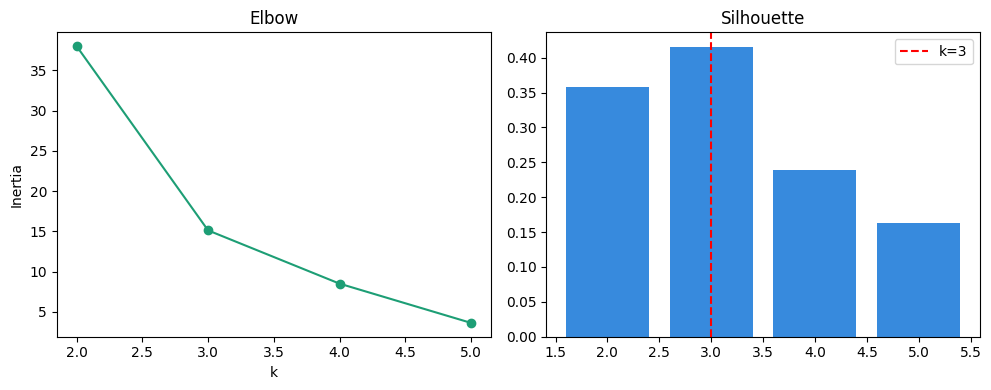


✅ K-Means: k=3, Silhouette=0.4157
year            cluster        zona_uhi
kota                                   
Bukittinggi           1  UHI Intensif 🔴
Padang                1  UHI Intensif 🔴
Padang Panjang        2    UHI Rendah 🟢
Pariaman              1  UHI Intensif 🔴
Payakumbuh            1  UHI Intensif 🔴
Sawahlunto            0    UHI Sedang 🟡
Solok                 0    UHI Sedang 🟡
💾 Model K-Means tersimpan!


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

pivot = df.pivot_table(index='kota', columns='year', values='lst_c_mean', aggfunc='mean')
pivot = pivot.ffill(axis=1).bfill(axis=1)
X = StandardScaler().fit_transform(pivot)

sil_scores, inertias = {}, []
K_RANGE = range(2, min(6, len(pivot)))
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores[k] = silhouette_score(X, lbl)

k_opt = max(sil_scores, key=sil_scores.get)
print('Silhouette scores:')
for k,s in sil_scores.items():
    print(f'  k={k}: {s:.4f}{" ← terpilih" if k==k_opt else ""}')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
ax1.plot(list(K_RANGE), inertias, 'o-', color='#1D9E75')
ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.bar(list(sil_scores.keys()), list(sil_scores.values()), color='#378ADD')
ax2.axvline(k_opt, color='red', ls='--', label=f'k={k_opt}')
ax2.set_title('Silhouette'); ax2.legend()
plt.tight_layout()
plt.savefig(str(BASE_DIR/'exports/kmeans_elbow.png'), dpi=150)
plt.show()

km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
pivot['cluster'] = km_final.fit_predict(X)

cml = pivot.drop('cluster',axis=1).join(pivot['cluster']).groupby('cluster').mean().mean(axis=1).sort_values(ascending=False)
labels = ['UHI Intensif 🔴','UHI Sedang 🟡','UHI Rendah 🟢','UHI Sangat Rendah 🔵']
LMAP  = {cid: labels[i] for i,cid in enumerate(cml.index)}
pivot['zona_uhi'] = pivot['cluster'].map(LMAP)

df = df.merge(pivot[['cluster','zona_uhi']].reset_index(), on='kota', how='left')

print(f'\n✅ K-Means: k={k_opt}, Silhouette={sil_scores[k_opt]:.4f}')
print(pivot[['cluster','zona_uhi']].to_string())

joblib.dump(km_final, str(BASE_DIR/'models/kmeans_model.pkl'))
print('💾 Model K-Means tersimpan!')

---
## 🤖 CELL ML-B — Random Forest Classifier (+30 poin)

Fitur: ['ndvi_mean', 'nbi_mean', 'mndwi_mean', 'lst_std', 'year_num', 'is_urban', 'delta_lst']
Sampel: 65 | Distribusi: {'Rendah': 28, 'Tinggi': 27, 'Sedang': 10}
F1 Macro CV: 0.5376 ± 0.0535
              precision    recall  f1-score   support

      Rendah       1.00      0.96      0.98        28
      Sedang       0.91      1.00      0.95        10
      Tinggi       1.00      1.00      1.00        27

    accuracy                           0.98        65
   macro avg       0.97      0.99      0.98        65
weighted avg       0.99      0.98      0.98        65



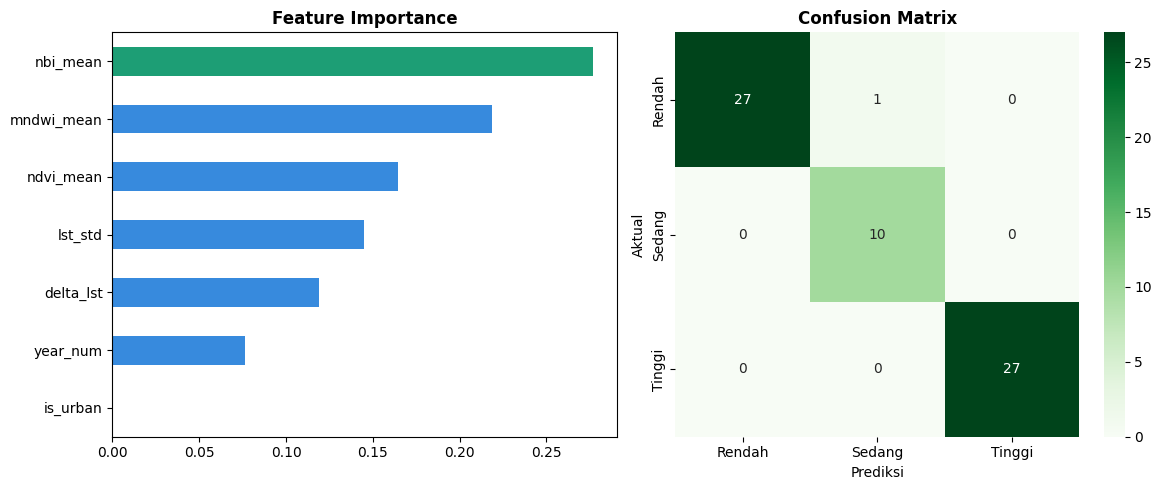

💾 Model RF tersimpan!


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

df['uhi_category'] = pd.cut(
    df['uhi_intensity'], bins=[-np.inf,-0.5,0.5,np.inf],
    labels=['Rendah','Sedang','Tinggi']
).astype(str)

ALL_FEATS = ['ndvi_mean','nbi_mean','mndwi_mean','lst_std','year_num','is_urban','delta_lst']
FEATURES  = [f for f in ALL_FEATS if f in df.columns and df[f].notna().sum() > 5]
print(f'Fitur: {FEATURES}')

df_ml = df[FEATURES+['uhi_category']].dropna()
X_rf, y_rf = df_ml[FEATURES], df_ml['uhi_category']
print(f'Sampel: {len(X_rf)} | Distribusi: {y_rf.value_counts().to_dict()}')

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
n_splits = min(5, max(2, y_rf.value_counts().min()))
if n_splits >= 2:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_rf, y_rf, cv=cv, scoring='f1_macro')
    print(f'F1 Macro CV: {scores.mean():.4f} ± {scores.std():.4f}')

rf.fit(X_rf, y_rf)
y_pred = rf.predict(X_rf)
print(classification_report(y_rf, y_pred, zero_division=0))

fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, axes = plt.subplots(1,2,figsize=(12,5))
fi.plot(kind='barh', ax=axes[0], color=['#1D9E75' if v==fi.max() else '#378ADD' for v in fi.values])
axes[0].set_title('Feature Importance', fontweight='bold')
lbl_order = [l for l in ['Rendah','Sedang','Tinggi'] if l in y_rf.unique()]
cm = confusion_matrix(y_rf, y_pred, labels=lbl_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=lbl_order, yticklabels=lbl_order)
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Aktual'); axes[1].set_xlabel('Prediksi')
plt.tight_layout()
plt.savefig(str(BASE_DIR/'exports/rf_result.png'), dpi=150)
plt.show()

joblib.dump(rf, str(BASE_DIR/'models/rf_model.pkl'))
print('💾 Model RF tersimpan!')

---
## 🤖 CELL ML-C — XGBoost Forecasting 2026–2030 (+30 poin)

  ✓ Bukittinggi: RMSE=0.226°C, MAE=0.170°C
  ✓ Padang: RMSE=0.590°C, MAE=0.371°C
  ✓ Padang Panjang: RMSE=1.918°C, MAE=1.318°C
  ✓ Pariaman: RMSE=0.539°C, MAE=0.351°C
  ✓ Payakumbuh: RMSE=1.065°C, MAE=0.794°C
  ✓ Sawahlunto: RMSE=0.745°C, MAE=0.515°C
  ✓ Solok: RMSE=0.650°C, MAE=0.422°C

✅ Forecasting selesai untuk 7 kota!
          kota   RMSE    MAE
   Bukittinggi 0.2259 0.1703
        Padang 0.5904 0.3713
Padang Panjang 1.9184 1.3180
      Pariaman 0.5391 0.3507
    Payakumbuh 1.0649 0.7940
    Sawahlunto 0.7450 0.5147
         Solok 0.6498 0.4222


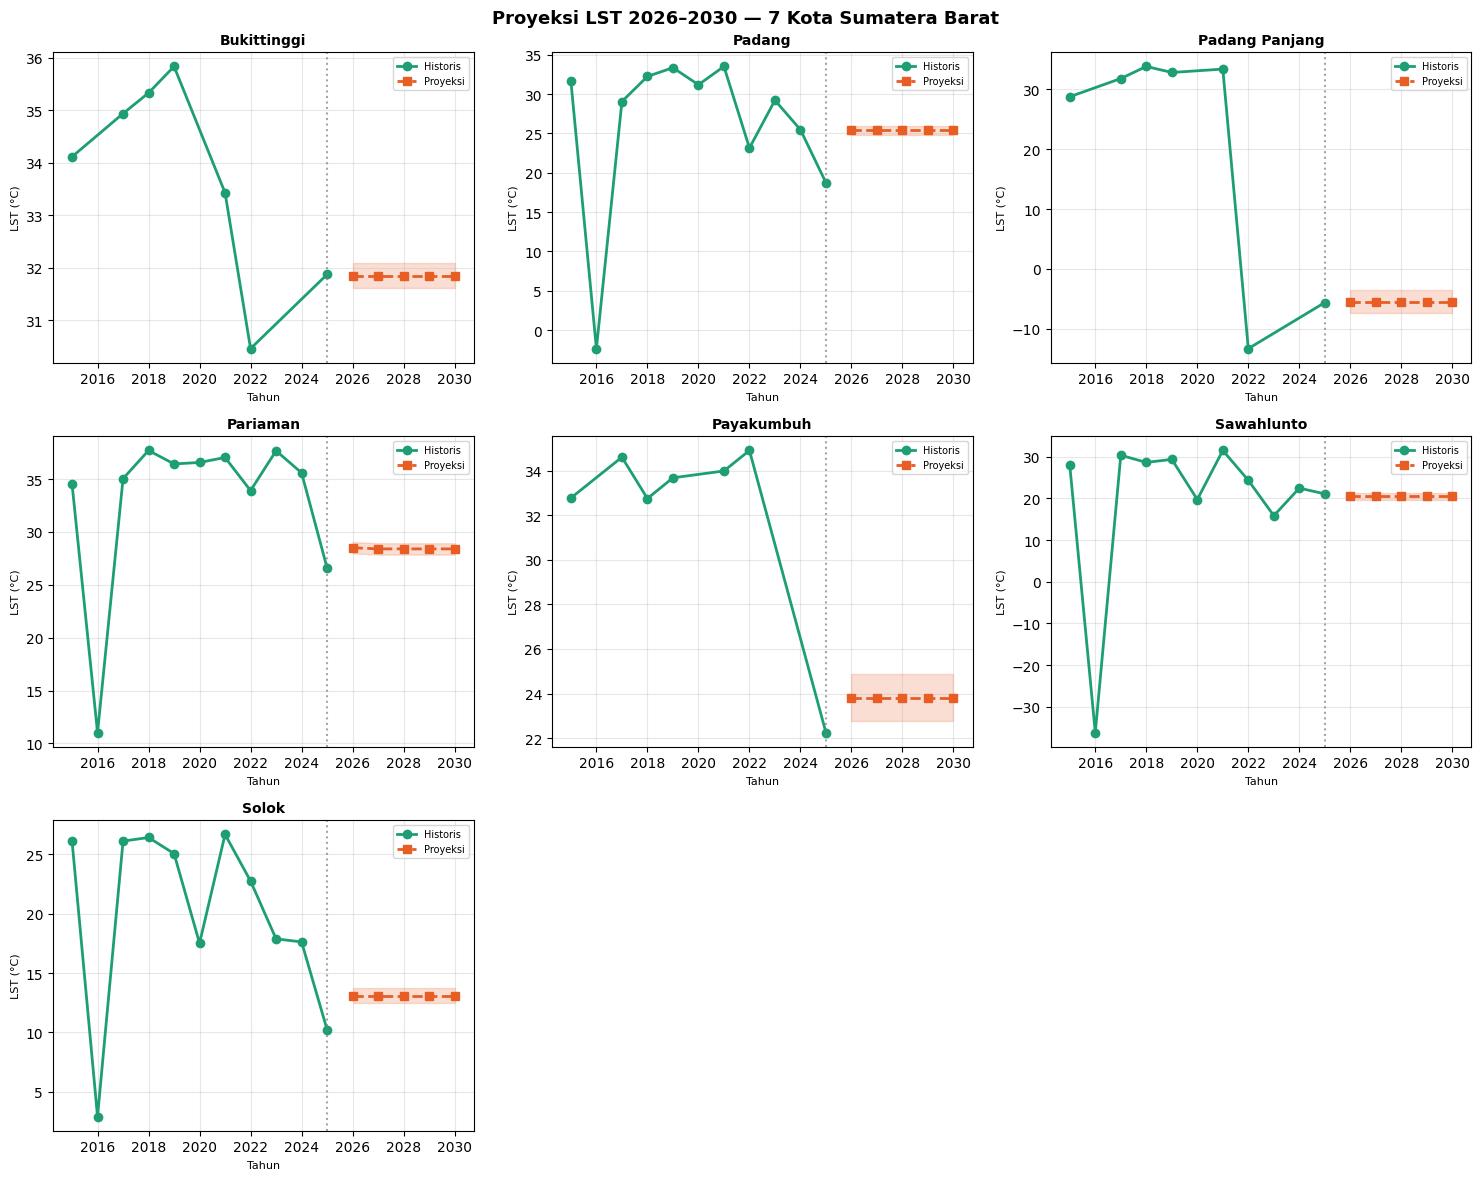

💾 Semua model XGBoost tersimpan!


In [13]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

FORECAST_YEARS = list(range(2026, 2031))
xgb_models, eval_results, forecast_records = {}, [], []

for kota_name in gdf_7kota['kota'].tolist():
    sub = df[df['kota']==kota_name].sort_values('year').copy()
    sub['lag1'] = sub['lst_c_mean'].shift(1)
    sub['lag2'] = sub['lst_c_mean'].shift(2)
    sub['lag3'] = sub['lst_c_mean'].shift(3)
    sub['trend']= sub['year'] - sub['year'].min()
    sub = sub.dropna(subset=['lag1','lag2','lag3','lst_c_mean'])

    if len(sub) < 4:
        print(f'  ⚠️  {kota_name}: {len(sub)} baris, skip'); continue

    base  = ['year_num','lag1','lag2','lag3','trend']
    extra = [f for f in ['ndvi_mean','uhi_intensity'] if f in sub.columns and sub[f].notna().sum()>2]
    FEATS = base + extra
    for ef in extra: sub[ef] = sub[ef].fillna(sub[ef].mean())

    model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                              subsample=0.8, random_state=42, verbosity=0)
    model.fit(sub[FEATS], sub['lst_c_mean'])
    y_pred = model.predict(sub[FEATS])
    rmse = np.sqrt(mean_squared_error(sub['lst_c_mean'], y_pred))
    mae  = mean_absolute_error(sub['lst_c_mean'], y_pred)
    eval_results.append({'kota':kota_name,'RMSE':round(rmse,4),'MAE':round(mae,4)})

    hist   = list(sub['lst_c_mean'].values)
    na_avg = {ef: sub[ef].mean() for ef in extra}
    ly_num = int(sub['year_num'].iloc[-1])
    base_y = int(df['year'].min())

    for fi2, fy in enumerate(FORECAST_YEARS):
        rd = {'year_num':ly_num+fi2+1,'lag1':hist[-1],'lag2':hist[-2],'lag3':hist[-3],'trend':fy-base_y}
        for ef in extra: rd[ef] = na_avg[ef]
        pred = float(model.predict(pd.DataFrame([rd]))[0])
        forecast_records.append({'kota':kota_name,'year':fy,
                                  'lst_forecast':round(pred,2),
                                  'lst_upper':round(pred+rmse,2),
                                  'lst_lower':round(pred-rmse,2)})
        hist.append(pred)

    xgb_models[kota_name] = model
    print(f'  ✓ {kota_name}: RMSE={rmse:.3f}°C, MAE={mae:.3f}°C')

df_eval     = pd.DataFrame(eval_results)
df_forecast = pd.DataFrame(forecast_records)
print(f'\n✅ Forecasting selesai untuk {len(xgb_models)} kota!')
print(df_eval.to_string(index=False))

# Plot
n_kota = len(gdf_7kota)
cols = 3; rows_n = (n_kota+cols-1)//cols
fig, axes = plt.subplots(rows_n, cols, figsize=(15, 4*rows_n))
axes = axes.flatten()
for i, kn in enumerate(gdf_7kota['kota'].tolist()):
    ax = axes[i]
    h  = df[df['kota']==kn].sort_values('year')
    fo = df_forecast[df_forecast['kota']==kn]
    ax.plot(h['year'], h['lst_c_mean'], 'o-', color='#1D9E75', lw=2, label='Historis')
    if len(fo)>0:
        ax.plot(fo['year'], fo['lst_forecast'], 's--', color='#E85D24', lw=2, label='Proyeksi')
        ax.fill_between(fo['year'], fo['lst_lower'], fo['lst_upper'], alpha=0.2, color='#E85D24')
    ax.axvline(2025, color='gray', ls=':', alpha=0.7)
    ax.set_title(kn, fontweight='bold', fontsize=10)
    ax.set_xlabel('Tahun',fontsize=8); ax.set_ylabel('LST (°C)',fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
for j in range(n_kota, len(axes)): axes[j].set_visible(False)
fig.suptitle('Proyeksi LST 2026–2030 — 7 Kota Sumatera Barat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR/'exports/lst_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(xgb_models, str(BASE_DIR/'models/xgb_models.pkl'))
print('💾 Semua model XGBoost tersimpan!')

---
## 💾 CELL SAVE — Simpan semua output final

In [14]:
df.to_csv(str(BASE_DIR/'processed/uhi_panel_data.csv'), index=False)
df_forecast.to_csv(str(BASE_DIR/'processed/uhi_forecast_2026_2030.csv'), index=False)
df_eval.to_csv(str(BASE_DIR/'processed/model_evaluation.csv'), index=False)
pivot.to_csv(str(BASE_DIR/'processed/kmeans_clustering_result.csv'))

print('='*55)
print('✅ SEMUA OUTPUT TERSIMPAN DI GOOGLE DRIVE')
print('='*55)
print(f'Baris data     : {len(df)}')
print(f'Kota tercakup  : {df["kota"].nunique()}')
print(f'Rentang tahun  : {df["year"].min()}–{df["year"].max()}')
print(f'Model tersimpan: kmeans_model.pkl, rf_model.pkl, xgb_models.pkl')
print('\n📥 Download ke lokal:')
print('   processed/uhi_panel_data.csv')
print('   processed/uhi_forecast_2026_2030.csv')
print('   processed/model_evaluation.csv')
print('   models/*.pkl')
print('   admin/7kota_sumbar.gpkg')
print('\n🚀 Selanjutnya: build Streamlit app di VSCode!')

✅ SEMUA OUTPUT TERSIMPAN DI GOOGLE DRIVE
Baris data     : 65
Kota tercakup  : 7
Rentang tahun  : 2015–2025
Model tersimpan: kmeans_model.pkl, rf_model.pkl, xgb_models.pkl

📥 Download ke lokal:
   processed/uhi_panel_data.csv
   processed/uhi_forecast_2026_2030.csv
   processed/model_evaluation.csv
   models/*.pkl
   admin/7kota_sumbar.gpkg

🚀 Selanjutnya: build Streamlit app di VSCode!
